In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
# Load the dataset
df = pd.read_csv('Alphabets_data.csv')

In [4]:
# Basic Exploration
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['letter'].value_counts())

Dataset Shape: (20000, 17)

Missing Values:
 letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

Class Distribution:
 letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64


In [5]:
# Features and Target
X = df.drop('letter', axis=1)
y = df['letter']

In [6]:
# Label Encoding the target alphabets (A-Z -> 0-25)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [7]:
# Data Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Split the dataset into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [9]:
def build_model(optimizer='adam', neurons=64, activation='relu'):
    model = Sequential([
        Dense(neurons, input_dim=X_train.shape[1], activation=activation), # Hidden Layer 1
        Dense(neurons // 2, activation=activation),                        # Hidden Layer 2
        Dense(26, activation='softmax')                                   # Output Layer (26 alphabets)
    ])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
# Basic ANN with default settings
baseline_model = build_model()
history = baseline_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Manually testing a few configurations to find the best performance
results = []
learning_rates = [0.001, 0.01]
activations = ['relu', 'tanh']

print("\nStarting Hyperparameter Tuning...")
for lr in learning_rates:
    for act in activations:
        model = build_model(optimizer=Adam(learning_rate=lr), activation=act)
        model.fit(X_train, y_train, epochs=10, verbose=0)
        val_acc = model.evaluate(X_test, y_test, verbose=0)[1]
        results.append({'lr': lr, 'activation': act, 'accuracy': val_acc})
        print(f"LR: {lr}, Activation: {act} -> Validation Accuracy: {val_acc:.4f}")


Starting Hyperparameter Tuning...
LR: 0.001, Activation: relu -> Validation Accuracy: 0.9020
LR: 0.001, Activation: tanh -> Validation Accuracy: 0.8842
LR: 0.01, Activation: relu -> Validation Accuracy: 0.9183
LR: 0.01, Activation: tanh -> Validation Accuracy: 0.9050


In [12]:
# Selecting the best parameters from our manual search
best_config = max(results, key=lambda x: x['accuracy'])
print("\nBest Configuration Found:", best_config)


Best Configuration Found: {'lr': 0.01, 'activation': 'relu', 'accuracy': 0.9182500243186951}


In [13]:
final_model = build_model(optimizer=Adam(learning_rate=best_config['lr']), activation=best_config['activation'])
final_model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

In [14]:
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [15]:
# Evaluation metrics
print("\nFinal Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Final Model Accuracy: 0.91375

Classification Report:
               precision    recall  f1-score   support

           A       0.98      0.95      0.96       149
           B       0.84      0.91      0.87       153
           C       0.95      0.74      0.83       137
           D       0.86      0.96      0.91       156
           E       0.84      0.94      0.88       141
           F       0.92      0.86      0.89       140
           G       0.70      0.96      0.81       160
           H       0.84      0.80      0.82       144
           I       0.95      0.90      0.93       146
           J       0.96      0.91      0.93       149
           K       0.96      0.83      0.89       130
           L       1.00      0.92      0.96       155
           M       0.98      0.94      0.96       168
           N       0.98      0.94      0.96       151
           O       0.93      0.86      0.90       145
           P       0.90      0.95      0.92       173
           Q       0.91  

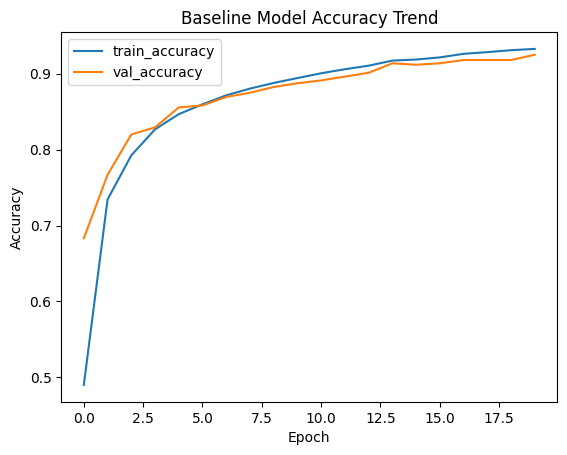

In [16]:
# Plotting Accuracy Trend
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Baseline Model Accuracy Trend')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()